In [26]:
import numpy as np
import matplotlib.pyplot as plt
from math import gamma as gamma_func, exp, factorial
import warnings
warnings.filterwarnings('ignore')

# Consistent style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded successfully!")


Libraries loaded successfully!


---
## **1. Definition and Basic Properties**

A stochastic process $(X_t)_{t \geq 0}$ is a **Lévy process** if it satisfies:

1. **$X_0 = 0$** almost surely
2. **Independent increments:** For any $0 \leq t_0 < t_1 < \cdots < t_n$, the random variables $X_{t_1}-X_{t_0}, X_{t_2}-X_{t_1}, \ldots, X_{t_n}-X_{t_{n-1}}$ are independent
3. **Stationary increments:** The distribution of $X_{t+s} - X_t$ depends only on $s$, not on $t$
4. **Continuity in probability:** For every $\epsilon > 0$, $\mathbb{P}(|X_{t+s} - X_t| > \epsilon) \to 0$ as $s \to 0$
5. **Càdlàg paths:** The sample paths are right-continuous with left limits

### Characteristic Function

Because of stationary independent increments, the characteristic function has the form:

$$\mathbb{E}\left[e^{iuX_t}\right] = e^{t\psi(u)}$$

where $\psi(u)$ is the **characteristic exponent** (or Lévy symbol).

### Key Examples

| Process | Paths | Jumps | Finite Variance? |
|---------|-------|-------|------------------|
| **Brownian motion** | Continuous | None | Yes |
| **Poisson process** | Piecewise constant | Unit jumps | Yes |
| **Compound Poisson** | Piecewise constant | Random jumps | Yes (if jumps have finite variance) |
| **Gamma process** | Purely increasing | Infinite jump activity | Yes |
| **Cauchy ($\alpha$-stable)** | Càdlàg | Heavy-tailed jumps | No (infinite variance) |


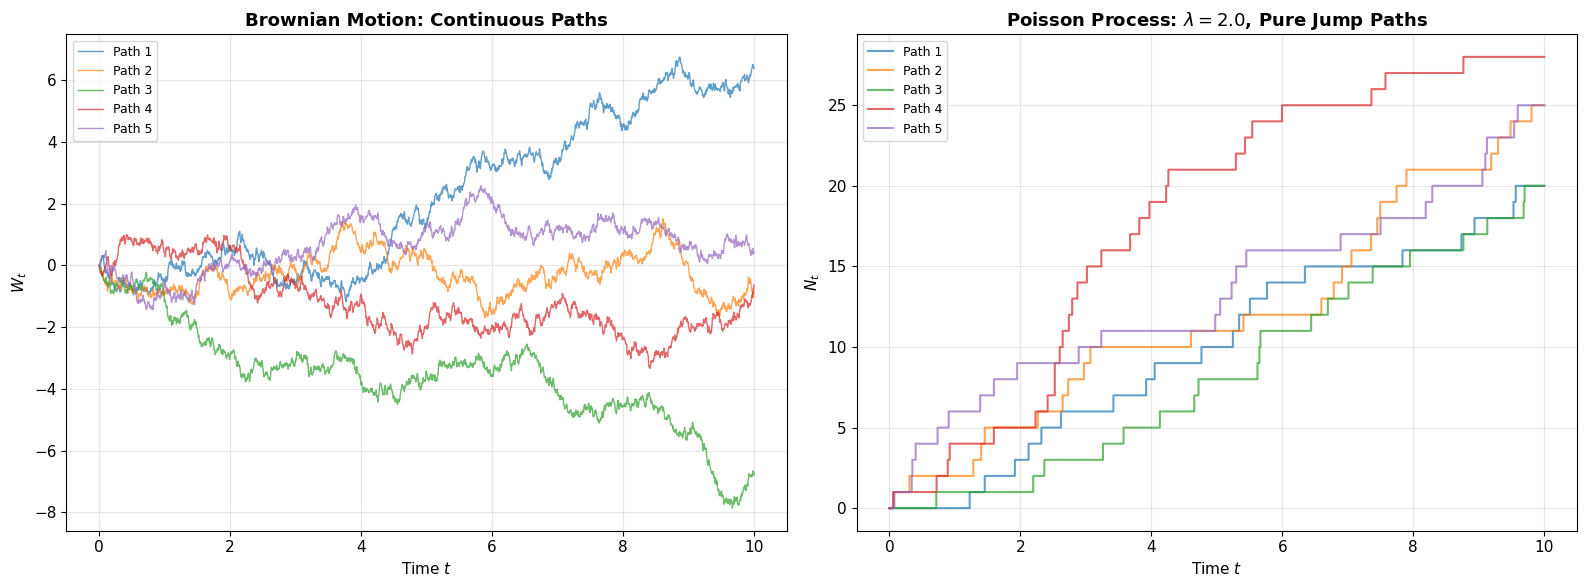

In [27]:
# ============================================================
# 2. The Two Extremes: Brownian Motion and Poisson
# ============================================================

np.random.seed(42)
T = 10.0
N = 2000
dt = T / N
t = np.linspace(0, T, N + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Brownian motion (continuous) ---
ax = axes[0]
for i in range(5):
    dW = np.random.normal(0, np.sqrt(dt), size=N)
    W = np.concatenate([[0], np.cumsum(dW)])
    ax.plot(t, W, alpha=0.7, linewidth=1, label=rf'Path {i+1}')
ax.set_title('Brownian Motion: Continuous Paths', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$W_t$', fontsize=11)
ax.legend(fontsize=9)

# --- Right: Poisson process (pure jump) ---
ax = axes[1]
lam = 2.0
for i in range(5):
    events = np.random.poisson(lam * dt, size=N)
    N_t = np.concatenate([[0], np.cumsum(events)])
    ax.step(t, N_t, where='post', alpha=0.7, linewidth=1.5, label=rf'Path {i+1}')
ax.set_title(rf'Poisson Process: $\lambda = {lam}$, Pure Jump Paths', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$N_t$', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## **3. Compound Poisson Processes**

A **compound Poisson process** superimposes random jump sizes onto Poisson arrival times:

$$X_t = \sum_{i=1}^{N_t} Y_i$$

where:
- $N_t$ is a Poisson process with rate $\lambda$
- $Y_1, Y_2, \ldots$ are i.i.d. jump sizes, independent of $N_t$

### Properties

- **Mean:** $\mathbb{E}[X_t] = \lambda t \, \mathbb{E}[Y]$
- **Variance:** $\text{Var}(X_t) = \lambda t \, \mathbb{E}[Y^2]$
- **Characteristic exponent:** $\psi(u) = \lambda \, (\phi_Y(u) - 1)$, where $\phi_Y$ is the characteristic function of $Y$

### Simulation

Exact simulation uses exponential inter-arrival times: if $\tau_i \sim \text{Exp}(\lambda)$, then jump $i$ occurs at time $T_i = \tau_1 + \cdots + \tau_i$.


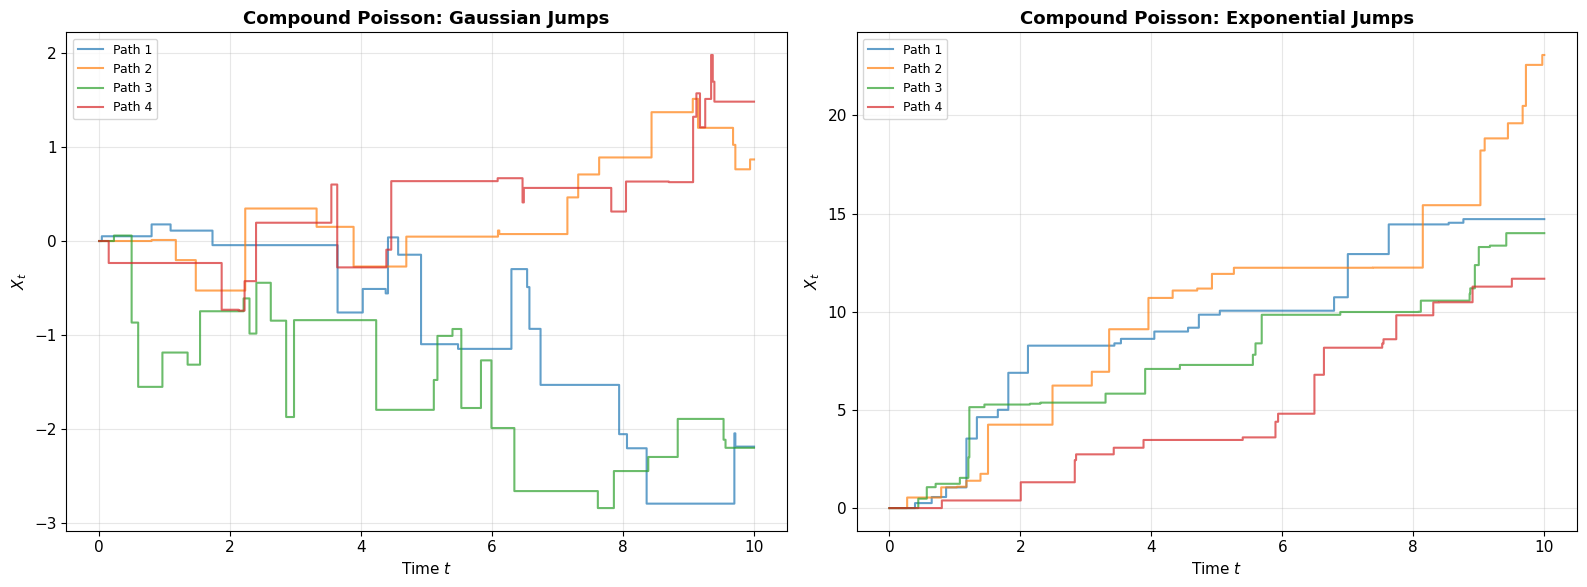

In [28]:
# ============================================================
# Compound Poisson: Exact Simulation via Inter-Arrival Times
# ============================================================

np.random.seed(7)

def simulate_compound_poisson(T, lam, jump_dist, N=2000):
    """Simulate compound Poisson via exact inter-arrival times."""
    # Generate more inter-arrival times than expected as a buffer
    inter = np.random.exponential(1.0 / lam, size=int(lam * T * 3))
    arrival_times = np.cumsum(inter)
    arrival_times = arrival_times[arrival_times <= T]
    n_jumps = len(arrival_times)
    jump_sizes = jump_dist(n_jumps)
    
    # Build path on a fine grid
    t_grid = np.linspace(0, T, N + 1)
    X = np.zeros(N + 1)
    for i, ti in enumerate(t_grid[1:], 1):
        count = np.sum(arrival_times <= ti)
        X[i] = np.sum(jump_sizes[:count])
    return t_grid, X, arrival_times, jump_sizes


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Gaussian jumps ---
ax = axes[0]
for i in range(4):
    t, X, arr, jumps = simulate_compound_poisson(
        10.0, 2.0, lambda n: np.random.normal(0, 0.5, n), N=2000
    )
    ax.step(t, X, where='post', alpha=0.7, linewidth=1.5, label=rf'Path {i+1}')
ax.set_title('Compound Poisson: Gaussian Jumps', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=9)

# --- Right: Exponential jumps (positive only) ---
ax = axes[1]
for i in range(4):
    t, X, arr, jumps = simulate_compound_poisson(
        10.0, 2.0, lambda n: np.random.exponential(0.8, n), N=2000
    )
    ax.step(t, X, where='post', alpha=0.7, linewidth=1.5, label=rf'Path {i+1}')
ax.set_title('Compound Poisson: Exponential Jumps', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## **4. The Lévy-Khintchine Representation**

Every Lévy process is characterized by its **characteristic exponent** $\psi(u)$ via the **Lévy-Khintchine formula**:

$$\psi(u) = i\gamma u - \frac{\sigma^2 u^2}{2} + \int_{\mathbb{R}} \left(e^{iux} - 1 - iux\mathbf{1}_{|x|<1}\right) \nu(dx)$$

where the **Lévy triplet** $(\gamma, \sigma^2, \nu)$ consists of:

| Component | Meaning |
|-----------|---------|
| $\gamma \in \mathbb{R}$ | Drift coefficient |
| $\sigma^2 \geq 0$ | Gaussian variance (Brownian part) |
| $\nu$ | Lévy measure: $\nu(A)$ = expected number of jumps per unit time with size in $A$ |

### Special Cases

- **Brownian motion with drift:** $\nu = 0$, so $\psi(u) = i\gamma u - \frac{\sigma^2 u^2}{2}$
- **Poisson($\lambda$):** $\sigma = 0$, $\nu = \lambda \delta_1$, so $\psi(u) = \lambda(e^{iu}-1)$
- **Compound Poisson:** $\sigma = 0$, $\nu(dx) = \lambda f_Y(x)dx$, so $\psi(u) = \lambda(\phi_Y(u)-1)$
- **Cauchy (1-stable):** $\sigma = 0$, $\nu(dx) = \frac{1}{\pi x^2}dx$, so $\psi(u) = -\gamma|u|$
- 

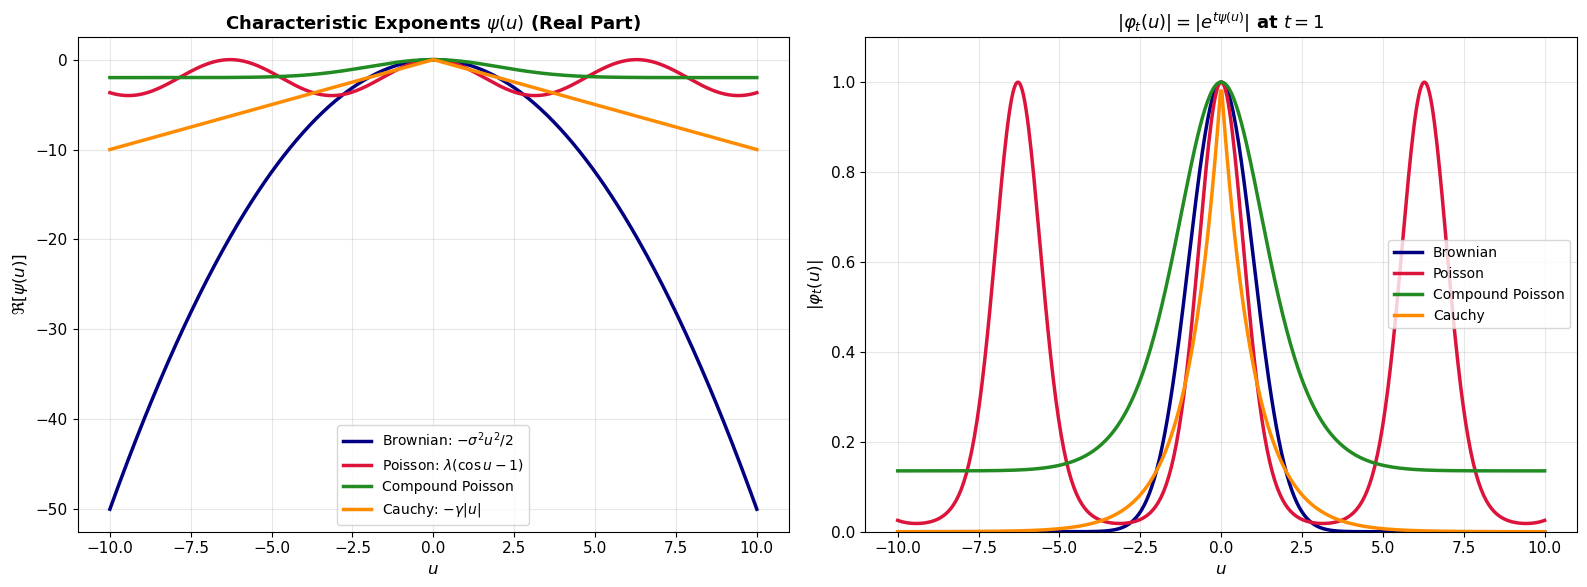

In [29]:
# ============================================================
# Characteristic Exponents: Visual Comparison
# ============================================================

np.random.seed(11)
u = np.linspace(-10, 10, 500)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Real parts of characteristic exponents ---
ax = axes[0]

# Brownian (drift zero for real part)
sigma = 1.0
psi_bm = -0.5 * sigma**2 * u**2
ax.plot(u, psi_bm, 'navy', linewidth=2.5, label=rf'Brownian: $-\sigma^2 u^2/2$')

# Poisson
lam = 2.0
psi_poisson = lam * (np.cos(u) - 1)
ax.plot(u, psi_poisson, 'crimson', linewidth=2.5, label=rf'Poisson: $\lambda(\cos u - 1)$')

# Compound Poisson with normal jumps
s_jump = 0.5
psi_cp = lam * (np.exp(-0.5 * s_jump**2 * u**2) - 1)
ax.plot(u, psi_cp, 'forestgreen', linewidth=2.5, label=rf'Compound Poisson')

# Cauchy (symmetric 1-stable)
gamma_c = 1.0
psi_cauchy = -gamma_c * np.abs(u)
ax.plot(u, psi_cauchy, 'darkorange', linewidth=2.5, label=rf'Cauchy: $-\gamma|u|$')

ax.set_title(r'Characteristic Exponents $\psi(u)$ (Real Part)', fontsize=13, fontweight='bold')
ax.set_xlabel('$u$', fontsize=12)
ax.set_ylabel(r'$\Re[\psi(u)]$', fontsize=12)
ax.legend(fontsize=10)

# --- Right: Characteristic function magnitude at t=1 ---
ax = axes[1]
t = 1.0
phi_bm = np.exp(t * psi_bm)
phi_poisson = np.exp(t * psi_poisson)
phi_cp = np.exp(t * psi_cp)
phi_cauchy = np.exp(t * psi_cauchy)

ax.plot(u, np.abs(phi_bm), 'navy', linewidth=2.5, label='Brownian')
ax.plot(u, np.abs(phi_poisson), 'crimson', linewidth=2.5, label='Poisson')
ax.plot(u, np.abs(phi_cp), 'forestgreen', linewidth=2.5, label='Compound Poisson')
ax.plot(u, np.abs(phi_cauchy), 'darkorange', linewidth=2.5, label='Cauchy')

ax.set_title(r'$|\varphi_t(u)| = |e^{t\psi(u)}|$ at $t=1$', fontsize=13, fontweight='bold')
ax.set_xlabel('$u$', fontsize=12)
ax.set_ylabel(r'$|\varphi_t(u)|$', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()


---
## **5. Gamma Process**

The **Gamma process** is a pure-jump Lévy process with **only positive increments**. For a process with shape rate $\alpha > 0$ and scale $\theta > 0$:

$$X_t \sim \Gamma(\alpha t, \theta) \quad \text{(shape } \alpha t \text{, scale } \theta\text{)}$$

### Properties

- **Mean:** $\mathbb{E}[X_t] = \alpha \theta t$
- **Variance:** $\text{Var}(X_t) = \alpha \theta^2 t$
- **Lévy measure:** $\nu(dx) = \frac{\alpha}{x} e^{-x/\theta} \mathbf{1}_{x>0} \, dx$
- **Infinite jump activity:** $\nu((0,\infty)) = \infty$, but $\int_0^1 x \, \nu(dx) < \infty$

The Gamma process has **infinitely many jumps** in any interval, but they are all positive and summable.


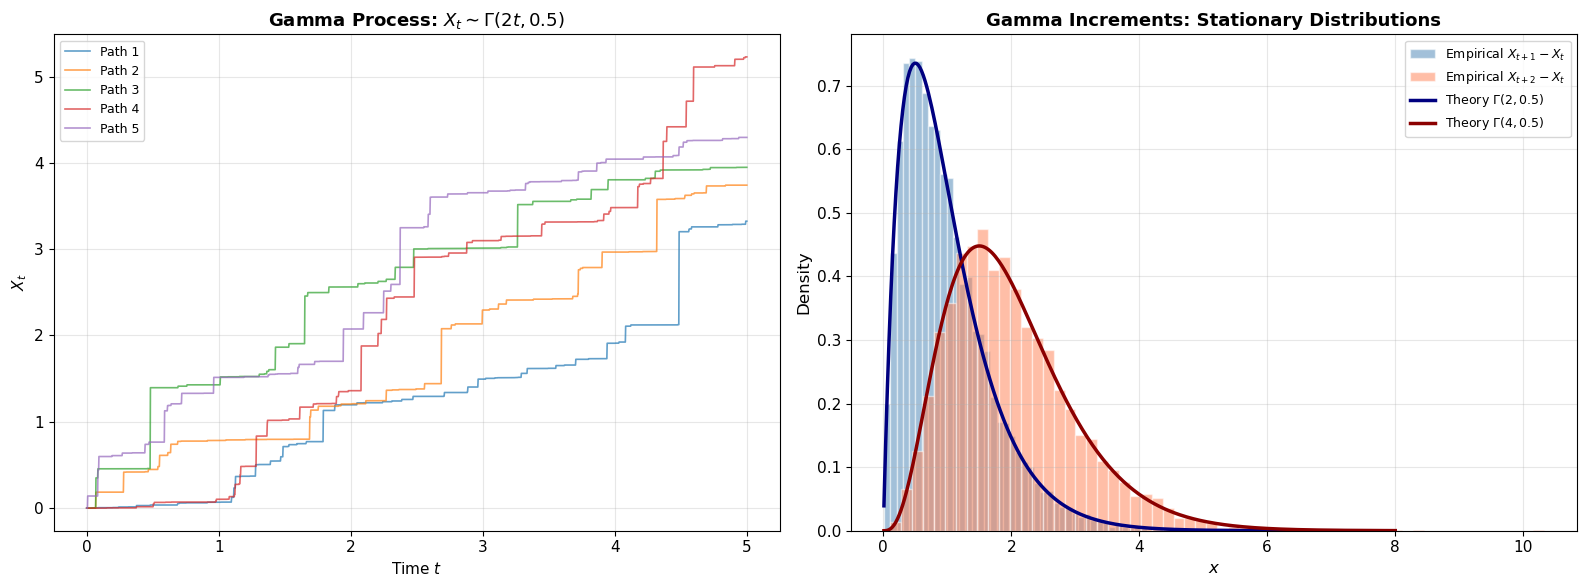

In [30]:
# ============================================================
# Gamma Process: Simulation and Increment Verification
# ============================================================

np.random.seed(3)

def simulate_gamma_process(T, shape_rate, scale, N=2000):
    """Gamma process: increments ~ Gamma(shape_rate * dt, scale)."""
    dt = T / N
    t = np.linspace(0, T, N + 1)
    increments = np.random.gamma(shape=shape_rate * dt, scale=scale, size=N)
    X = np.concatenate([[0], np.cumsum(increments)])
    return t, X


def gamma_pdf(x, shape, scale):
    """Manual Gamma PDF to avoid scipy dependency."""
    x = np.asarray(x, dtype=float)
    x_safe = np.where(x <= 0, 1e-10, x)
    pdf = (x_safe**(shape - 1) * np.exp(-x_safe / scale)) / (scale**shape * gamma_func(shape))
    pdf = np.where(x <= 0, 0.0, pdf)
    return pdf


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Sample paths ---
ax = axes[0]
for i in range(5):
    t, X = simulate_gamma_process(5.0, 2.0, 0.5, N=2000)
    ax.plot(t, X, alpha=0.7, linewidth=1.2, label=rf'Path {i+1}')
ax.set_title(r'Gamma Process: $X_t \sim \Gamma(2t, 0.5)$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=9)

# --- Right: Increment distributions for t=1 and t=2 ---
ax = axes[1]
n_sims = 10000
inc_1 = np.random.gamma(shape=2.0, scale=0.5, size=n_sims)
inc_2 = np.random.gamma(shape=4.0, scale=0.5, size=n_sims)

ax.hist(inc_1, bins=60, density=True, alpha=0.5, color='steelblue',
        edgecolor='white', label='Empirical $X_{t+1} - X_t$')
ax.hist(inc_2, bins=60, density=True, alpha=0.5, color='coral',
        edgecolor='white', label='Empirical $X_{t+2} - X_t$')

x_range = np.linspace(0.01, 8, 300)
ax.plot(x_range, gamma_pdf(x_range, 2.0, 0.5), 'navy', linewidth=2.5,
        label=rf'Theory $\Gamma(2, 0.5)$')
ax.plot(x_range, gamma_pdf(x_range, 4.0, 0.5), 'darkred', linewidth=2.5,
        label=rf'Theory $\Gamma(4, 0.5)$')

ax.set_title('Gamma Increments: Stationary Distributions', fontsize=13, fontweight='bold')
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## **6. Stable and Cauchy Processes**

A **strictly $\alpha$-stable process** satisfies the scaling property:

$$X_{ct} \stackrel{d}{=} c^{1/\alpha} X_t \quad \text{for all } c > 0$$

The **Cauchy process** is the symmetric $\alpha$-stable process with $\alpha = 1$.

### Key Features

- **Characteristic exponent:** $\psi(u) = -\gamma^\alpha |u|^\alpha$ (symmetric case)
- **For Cauchy ($\alpha=1$):** $\psi(u) = -\gamma |u|$
- **No finite variance** when $\alpha < 2$
- **Heavy tails:** $\mathbb{P}(|X_1| > x) \sim C x^{-\alpha}$ as $x \to \infty$

The paths exhibit **occasional very large jumps**, in stark contrast to the continuous Brownian path.


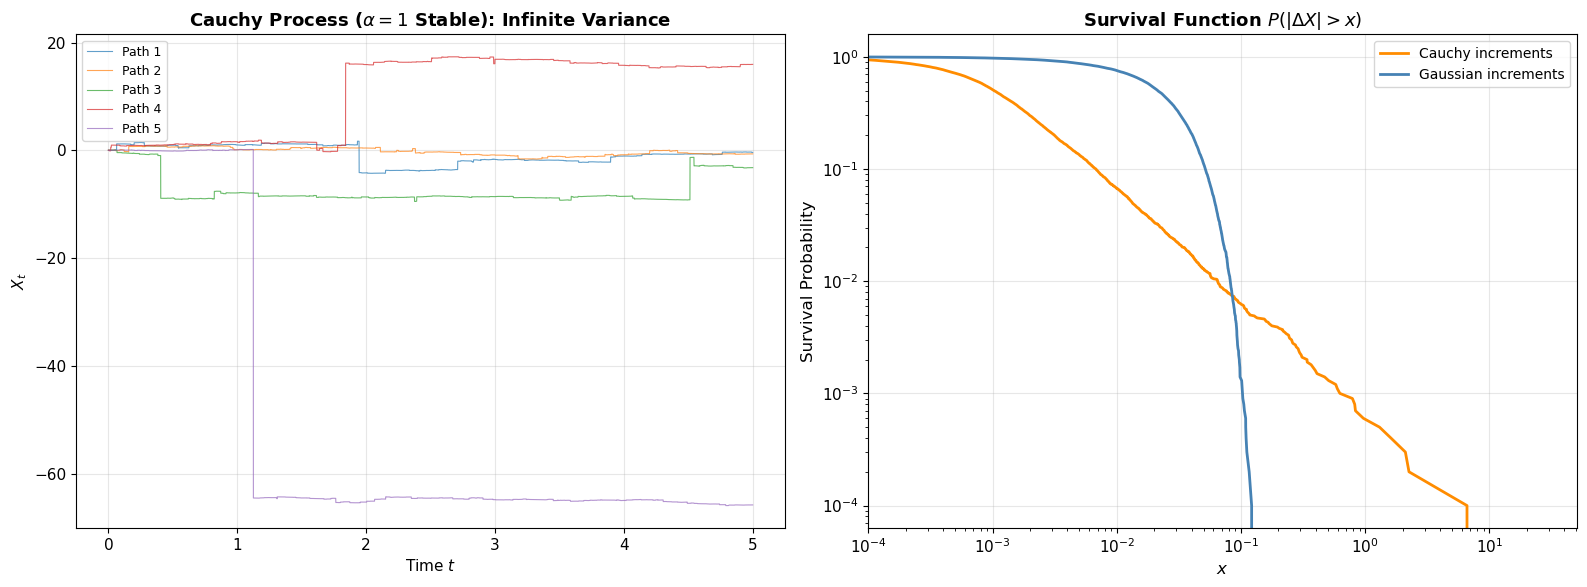

In [32]:
# ============================================================
# Cauchy Process (1-Stable): Paths and Heavy Tails
# ============================================================

np.random.seed(99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Cauchy process paths ---
ax = axes[0]
T = 5.0
N = 5000
dt = T / N
t = np.linspace(0, T, N + 1)
gamma_c = 1.0

for i in range(5):
    # Sum of i.i.d. Cauchy(0, gamma*dt) increments
    increments = np.random.standard_cauchy(size=N) * gamma_c * dt
    X = np.concatenate([[0], np.cumsum(increments)])
    ax.plot(t, X, alpha=0.7, linewidth=0.8, label=rf'Path {i+1}')
ax.set_title(r'Cauchy Process ($\alpha=1$ Stable): Infinite Variance', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=9)

# --- Right: Heavy tails vs Gaussian ---
ax = axes[1]
n_samples = 10000
cauchy_incs = np.random.standard_cauchy(size=n_samples) * gamma_c * dt
normal_incs = np.random.normal(0, np.sqrt(dt), size=n_samples)


def plot_survival(ax, data, color, label):
    sorted_abs = np.sort(np.abs(data))
    survival = 1.0 - np.arange(1, len(sorted_abs) + 1) / len(sorted_abs)
    ax.loglog(sorted_abs, survival, color=color, linewidth=2, label=label)


plot_survival(ax, cauchy_incs, 'darkorange', 'Cauchy increments')
plot_survival(ax, np.abs(normal_incs), 'steelblue', 'Gaussian increments')

ax.set_title(r'Survival Function $P(|\Delta X| > x)$', fontsize=13, fontweight='bold')
ax.set_xlabel('$x$', fontsize=12)
ax.set_ylabel('Survival Probability', fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(left=1e-4)

plt.tight_layout()
plt.show()


---
## **7. The Lévy-Itô Decomposition**

The **Lévy-Itô decomposition** states that any Lévy process can be written as the sum of four independent components:

$$X_t = \underbrace{\gamma t}_{\text{drift}} + \underbrace{\sigma W_t}_{\text{Brownian}} + \underbrace{\sum_{s \leq t, |\Delta X_s| \geq 1} \Delta X_s}_{\text{large jumps}} + \underbrace{\sum_{s \leq t, |\Delta X_s| < 1} (\Delta X_s - t\mathbb{E}[\Delta X_s])}_{\text{compensated small jumps}}$$

### Interpretation

| Component | Behavior | Variance |
|-----------|----------|----------|
| **Drift** | Deterministic linear trend | Zero |
| **Brownian** | Continuous fluctuations | Finite |
| **Large jumps** | Compound Poisson (countable jumps) | Finite |
| **Small jumps** | Martingale with infinite jump activity | Can be infinite |

For processes with finite Lévy measure ($\int \nu(dx) < \infty$), the small-jump part vanishes and we have a **jump-diffusion**:

$$X_t = \gamma t + \sigma W_t + \sum_{i=1}^{N_t} Y_i$$


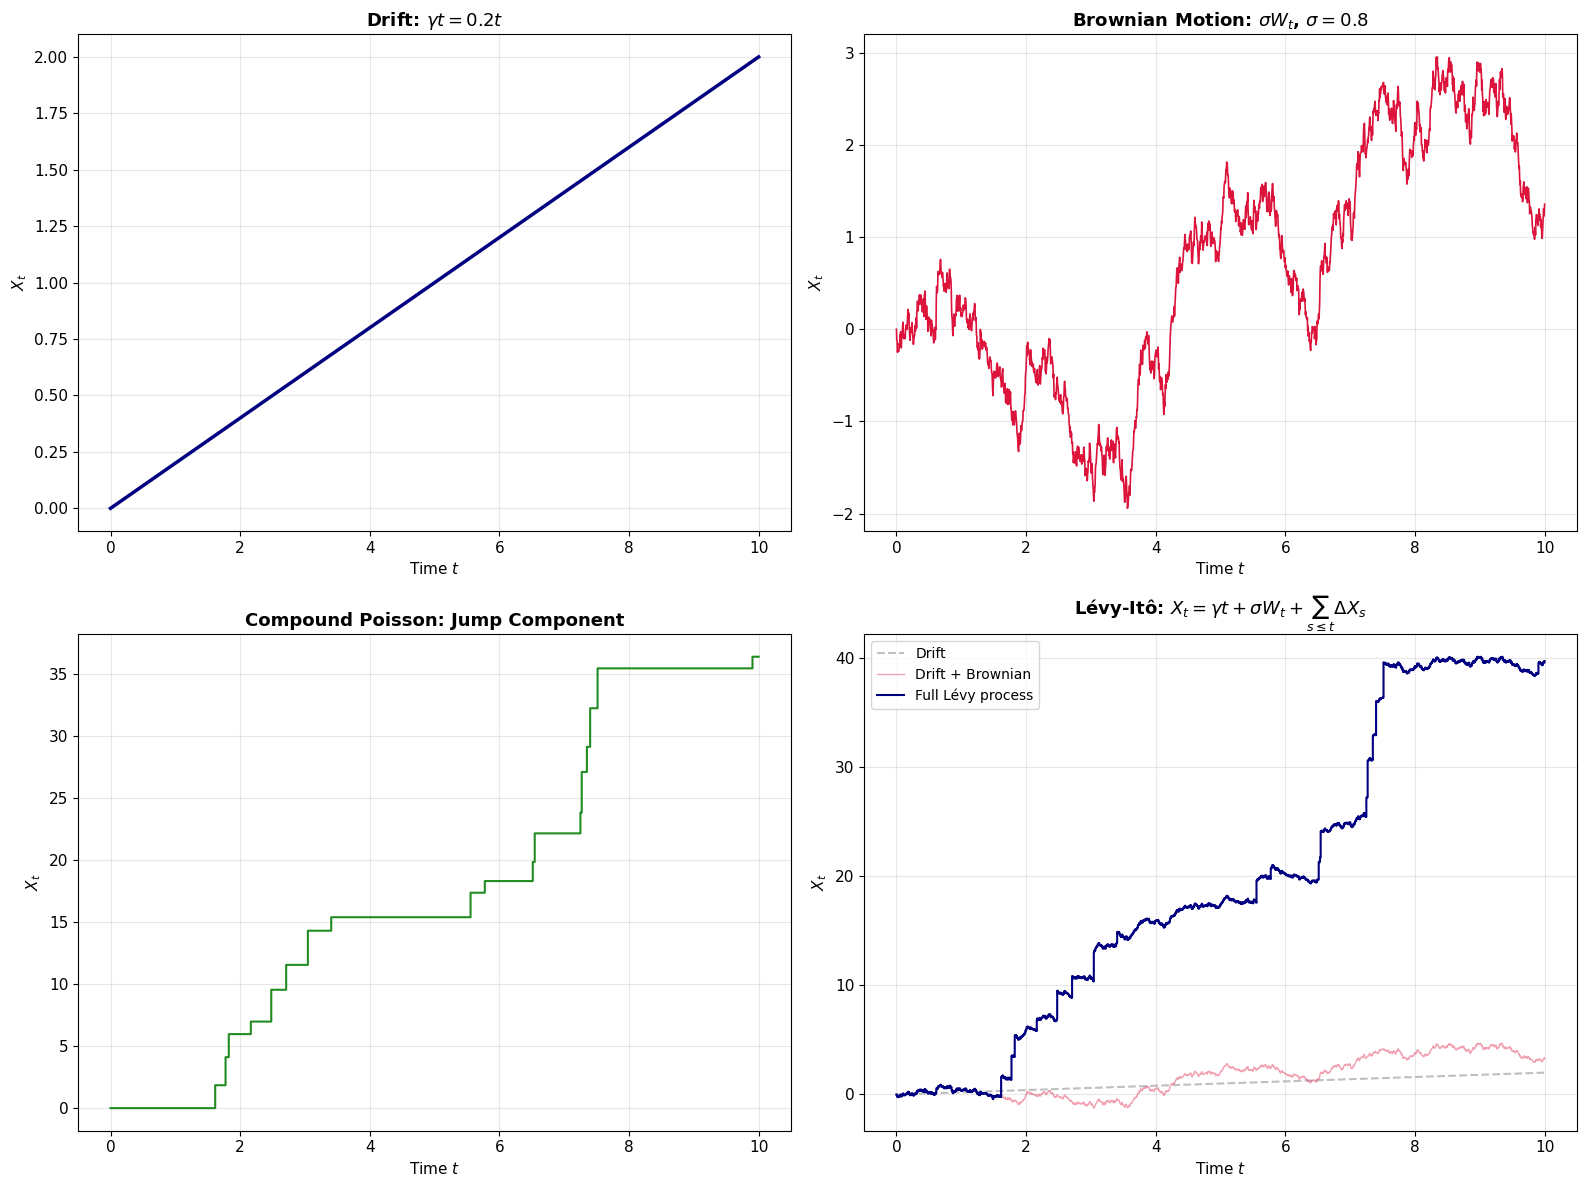

In [33]:
# ============================================================
# Lévy-Itô Decomposition: Building a Jump-Diffusion
# ============================================================

np.random.seed(55)

T = 10.0
N = 2000
dt = T / N
t = np.linspace(0, T, N + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Parameters
mu_drift = 0.2
sigma = 0.8
lam = 1.5

# 1. Drift
ax = axes[0, 0]
drift = mu_drift * t
ax.plot(t, drift, 'navy', linewidth=2.5)
ax.set_title(rf'Drift: $\gamma t = {mu_drift}t$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)

# 2. Brownian motion
ax = axes[0, 1]
dW = np.random.normal(0, np.sqrt(dt), size=N)
W = np.concatenate([[0], np.cumsum(dW)])
ax.plot(t, W, 'crimson', linewidth=1.2)
ax.set_title(rf'Brownian Motion: $\sigma W_t$, $\sigma={sigma}$', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)

# 3. Compound Poisson (big jumps)
ax = axes[1, 0]
inter = np.random.exponential(1.0 / lam, size=int(lam * T * 3))
arrivals = np.cumsum(inter)
arrivals = arrivals[arrivals <= T]
n_jumps = len(arrivals)
jumps = np.random.normal(2.0, 1.0, size=n_jumps)

X_cp = np.zeros(N + 1)
for i, ti in enumerate(t[1:], 1):
    count = np.sum(arrivals <= ti)
    X_cp[i] = np.sum(jumps[:count])
ax.step(t, X_cp, where='post', color='forestgreen', linewidth=1.5)
ax.set_title('Compound Poisson: Jump Component', fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)

# 4. Full Lévy process = sum of all three
ax = axes[1, 1]
X_full = drift + W + X_cp
ax.plot(t, drift, '--', color='gray', alpha=0.5, label='Drift')
ax.plot(t, drift + W, '-', color='crimson', alpha=0.4, linewidth=1, label='Drift + Brownian')
ax.step(t, X_full, where='post', color='navy', linewidth=1.5, label='Full Lévy process')
ax.set_title(r"Lévy-Itô: $X_t = \gamma t + \sigma W_t + \sum_{s\leq t} \Delta X_s$", fontsize=13, fontweight='bold')
ax.set_xlabel('Time $t$', fontsize=11)
ax.set_ylabel('$X_t$', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


---
## **8. Stationary Increments: Empirical Verification**

A defining property of Lévy processes is that increments over disjoint intervals of the **same length** are i.i.d. We verify this empirically for four processes:

- **Brownian motion:** increments $\sim \mathcal{N}(0, \Delta t)$
- **Poisson process:** increments $\sim \text{Poisson}(\lambda \Delta t)$
- **Compound Poisson:** distribution determined by jump law
- **Gamma process:** increments $\sim \Gamma(\alpha \Delta t, \theta)$

The histograms below confirm that the empirical distributions match the theoretical predictions.


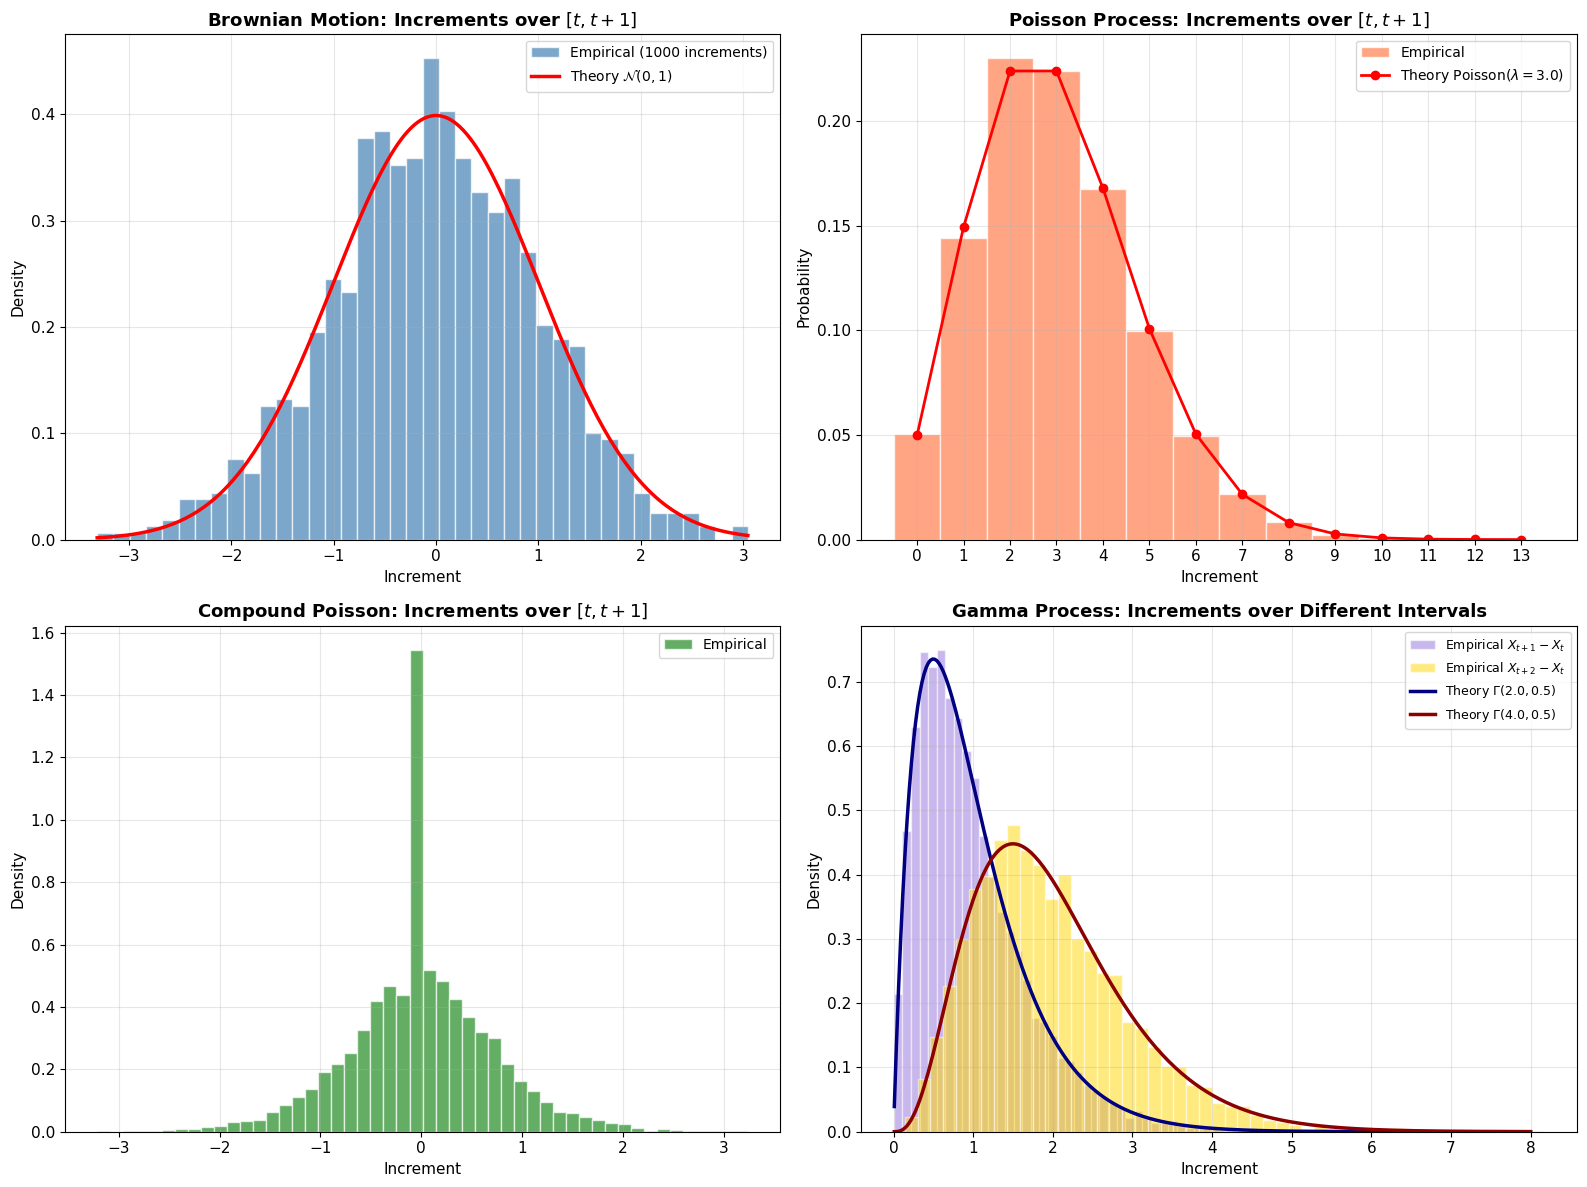

In [41]:
# ============================================================
# Stationary Increments: Empirical Verification
# ============================================================

# Self-contained imports (in case this cell is run standalone)
from math import gamma as math_gamma, factorial, exp
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))


# --- Brownian increments: longer path for good statistics ---
ax = axes[0, 0]
T = 1000.0          # Long path to extract many non-overlapping unit increments
N = 500000
dt = T / N
dW = np.random.normal(0, np.sqrt(dt), size=N)
W = np.concatenate([[0], np.cumsum(dW)])

inc_length = int(round(1.0 / dt))
max_possible = (len(W) - 1) // inc_length
n_incs = min(2000, max_possible)

increments_bm = np.array([
    W[(i + 1) * inc_length] - W[i * inc_length]
    for i in range(n_incs)
])

ax.hist(increments_bm, bins=40, density=True, alpha=0.7, color='steelblue',
        edgecolor='white', label=rf'Empirical ({n_incs} increments)')
x_theory = np.linspace(increments_bm.min(), increments_bm.max(), 200)
y_theory = (1.0 / np.sqrt(2 * np.pi * 1.0)) * np.exp(-x_theory**2 / 2.0)

# FIX: use plain raw string (no f-string) because there is no variable to insert
#      and {N} would be parsed as the Python variable N = 500000
ax.plot(x_theory, y_theory, 'r-', linewidth=2.5,
        label=r'Theory $\mathcal{N}(0, 1)$')

ax.set_title('Brownian Motion: Increments over $[t, t+1]$', fontsize=13, fontweight='bold')
ax.set_xlabel('Increment', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)


# --- Poisson increments ---
ax = axes[0, 1]
lam = 3.0
n_intervals = 10000
increments_poisson = np.random.poisson(lam, size=n_intervals)

max_val = int(increments_poisson.max()) + 2
bins_poisson = np.arange(-0.5, max_val + 0.5, 1)
ax.hist(increments_poisson, bins=bins_poisson, density=True, alpha=0.7, color='coral',
        edgecolor='white', label='Empirical')
k_vals = np.arange(0, max_val)
pmf_theory = np.array([exp(-lam) * (lam**k) / factorial(int(k)) for k in k_vals])
ax.plot(k_vals, pmf_theory, 'ro-', linewidth=2, markersize=6, label=rf'Theory Poisson($\lambda={lam}$)')
ax.set_title('Poisson Process: Increments over $[t, t+1]$', fontsize=13, fontweight='bold')
ax.set_xlabel('Increment', fontsize=11)
ax.set_ylabel('Probability', fontsize=11)
ax.legend(fontsize=10)
ax.set_xticks(k_vals)


# --- Compound Poisson increments ---
ax = axes[1, 0]
lam_cp = 2.0
n_intervals = 10000
increments_cp = []
for _ in range(n_intervals):
    n_jumps = np.random.poisson(lam_cp)
    if n_jumps > 0:
        jumps = np.random.normal(0, 0.5, size=n_jumps)
        increments_cp.append(np.sum(jumps))
    else:
        increments_cp.append(0.0)
increments_cp = np.array(increments_cp)

ax.hist(increments_cp, bins=50, density=True, alpha=0.7, color='forestgreen',
        edgecolor='white', label='Empirical')
ax.set_title('Compound Poisson: Increments over $[t, t+1]$', fontsize=13, fontweight='bold')
ax.set_xlabel('Increment', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=10)


# --- Gamma increments ---
ax = axes[1, 1]
shape_rate = 2.0
scale = 0.5
n_intervals = 10000
inc_g1 = np.random.gamma(shape=shape_rate * 1.0, scale=scale, size=n_intervals)
inc_g2 = np.random.gamma(shape=shape_rate * 2.0, scale=scale, size=n_intervals)

ax.hist(inc_g1, bins=50, density=True, alpha=0.5, color='mediumpurple',
        edgecolor='white', label='Empirical $X_{t+1}-X_t$')
ax.hist(inc_g2, bins=50, density=True, alpha=0.5, color='gold',
        edgecolor='white', label='Empirical $X_{t+2}-X_t$')

# Local Gamma PDF (no dependency on earlier cells)
def gamma_pdf_local(x, shape, scale):
    x = np.asarray(x, dtype=float)
    x_safe = np.where(x <= 0, 1e-10, x)
    pdf = (x_safe**(shape - 1) * np.exp(-x_safe / scale)) / (scale**shape * math_gamma(shape))
    pdf = np.where(x <= 0, 0.0, pdf)
    return pdf

x_range = np.linspace(0.01, 8, 300)
ax.plot(x_range, gamma_pdf_local(x_range, shape_rate * 1.0, scale), 'navy', linewidth=2.5,
        label=rf'Theory $\Gamma({shape_rate}, {scale})$')
ax.plot(x_range, gamma_pdf_local(x_range, shape_rate * 2.0, scale), 'darkred', linewidth=2.5,
        label=rf'Theory $\Gamma({shape_rate * 2}, {scale})$')

ax.set_title('Gamma Process: Increments over Different Intervals', fontsize=13, fontweight='bold')
ax.set_xlabel('Increment', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## **9. Summary**

| Process | $\psi(u)$ | Path Type | Key Feature |
|---------|-----------|-----------|-------------|
| **Brownian + drift** | $i\gamma u - \frac{\sigma^2 u^2}{2}$ | Continuous | Gaussian, everywhere dense |
| **Poisson** | $\lambda(e^{iu}-1)$ | Piecewise constant | Unit jumps, counting measure |
| **Compound Poisson** | $\lambda(\phi_Y(u)-1)$ | Piecewise constant | Random jump sizes |
| **Gamma** | $\alpha \log(1 - i\theta u)$ | Purely increasing | Infinite jump activity, positive |
| **Cauchy ($\alpha$-stable)** | $-\gamma|u|^\alpha$ | Càdlàg, heavy jumps | Infinite variance, self-similar |

### Key Formulas

**Characteristic function:** $\mathbb{E}[e^{iuX_t}] = e^{t\psi(u)}$

**Lévy-Khintchine:**
$$\psi(u) = i\gamma u - \frac{\sigma^2 u^2}{2} + \int_{\mathbb{R}} (e^{iux} - 1 - iux\mathbf{1}_{|x|<1}) \nu(dx)$$

**Lévy-Itô:**
$$X_t = \gamma t + \sigma W_t + \text{(large jumps)} + \text{(compensated small jumps)}$$

### References

1. **Sato, K.** (1999). *Lévy Processes and Infinitely Divisible Distributions*. Cambridge University Press.
2. **Applebaum, D.** (2009). *Lévy Processes and Stochastic Calculus* (2nd ed.). Cambridge University Press.
3. **Cont, R. & Tankov, P.** (2004). *Financial Modelling with Jump Processes*. Chapman & Hall/CRC.
4. **Bertoin, J.** (1996). *Lévy Processes*. Cambridge University Press.


